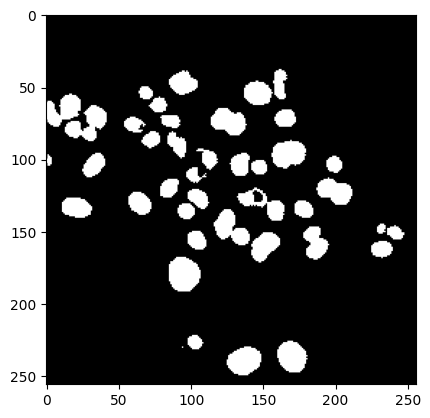

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

# -----------------------
# Model and Weight
# -----------------------


class DoubleConv(nn.Module):
    """
    Deux blocks de convolutions successifs :
    Conv2d : Convolution entre une matrice et un noyau
    BatchNorm2d : Normalisation par lots
    ReLU : Fonction d'activation
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class DownBlock(nn.Module):
    """
    Encoder : sous-échantillonnage de l'image
    Résultat de la double convolution puis application d'un max-pooling sur une matrice pour réduire les dimensions de cette matrice
    """

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = DoubleConv(in_channels, out_channels)
        self.down_sample = nn.MaxPool2d(2)

    def forward(self, x):
        skip_out = self.double_conv(x)
        down_out = self.down_sample(skip_out)
        return (down_out, skip_out)


class UpBlock(nn.Module):
    """
    Decoder : sur-échantillonnage de l'image
    nn.ConvTranspose2d : Concatenation de la couche précédente avec la sortie du max-pooling du même niveau
    DoubleConv : Application de deux blocks de convolutions
    """

    def __init__(self, in_channels, out_channels, up_sample_mode):
        super().__init__()
        if up_sample_mode == 'conv_transpose':
            self.up_sample = nn.ConvTranspose2d(
                in_channels - out_channels,
                in_channels - out_channels,
                kernel_size=2,
                stride=2,
            )
        elif up_sample_mode == 'bilinear':
            self.up_sample = nn.Upsample(
                scale_factor=2, mode='bilinear', align_corners=True
            )
        else:
            raise ValueError(
                'Unsupported `up_sample_mode` (can take one of `conv_transpose` or `bilinear`)'
            )
        self.double_conv = DoubleConv(in_channels, out_channels)

    def forward(self, down_input, skip_input):
        x = self.up_sample(down_input)
        x = torch.cat([x, skip_input], dim=1)
        return self.double_conv(x)


class UNet(nn.Module):
    """
    UNet pour une segmentation binaire : classe 0 fond / classe 1 objet
    Hyperparamètres :
    - Nombre de filtre
    """

    def __init__(
        self, n_filters, out_classes=2, up_sample_mode='conv_transpose'
    ):
        super().__init__()
        self.up_sample_mode = up_sample_mode
        # Encoder : Downsampling Path
        self.down_conv1 = DownBlock(3, n_filters * 4)
        self.down_conv2 = DownBlock(n_filters * 4, n_filters * 8)
        self.down_conv3 = DownBlock(n_filters * 8, n_filters * 16)
        self.down_conv4 = DownBlock(n_filters * 16, n_filters * 32)
        # Bottleneck
        self.double_conv = DoubleConv(n_filters * 32, n_filters * 64)
        # Decoder : Upsampling Path
        self.up_conv4 = UpBlock(
            n_filters * 32 + n_filters * 64,
            n_filters * 32,
            self.up_sample_mode,
        )
        self.up_conv3 = UpBlock(
            n_filters * 16 + n_filters * 32,
            n_filters * 16,
            self.up_sample_mode,
        )
        self.up_conv2 = UpBlock(
            n_filters * 8 + n_filters * 16, n_filters * 8, self.up_sample_mode
        )
        self.up_conv1 = UpBlock(
            n_filters * 8 + n_filters * 4, n_filters * 4, self.up_sample_mode
        )
        # Final Convolution
        self.conv_last = nn.Conv2d(n_filters * 4, out_classes, kernel_size=1)

    def forward(self, x):
        x, skip1_out = self.down_conv1(x)
        x, skip2_out = self.down_conv2(x)
        x, skip3_out = self.down_conv3(x)
        x, skip4_out = self.down_conv4(x)
        x = self.double_conv(x)
        x = self.up_conv4(x, skip4_out)
        x = self.up_conv3(x, skip3_out)
        x = self.up_conv2(x, skip2_out)
        x = self.up_conv1(x, skip1_out)
        x = self.conv_last(x)
        return x


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MODEL_PATH = r'C:\Users\KiloO\Formation\Exercice2-Code\best_UNet.pt'

model = UNet(n_filters=5)
state_dict = torch.load(MODEL_PATH, map_location=DEVICE)

model.load_state_dict(state_dict)
model.to(DEVICE)
model.eval()

# -----------------------
# import image and inference
# -----------------------
image = cv2.imread(r'C:\Users\KiloO\Formation\Exercice2-Code\img_2.png')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

image = image.astype(np.float32)

img_tensor = torch.from_numpy(image).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    output = model(img_tensor)

pred = torch.argmax(output, dim=1)
pred = pred.squeeze().cpu().numpy()
pred = np.where(pred == 0, 1, 0)

plt.imshow(pred, cmap='gray')